In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import json
import seaborn as sns
from dataclasses import dataclass, asdict
from ml_enhance import QuantumFPFileLoader, QuantumFPDatasetBuilder, ConformerAggregator

In [3]:
errors = pd.read_json("../data/QM9/error_batches.json")

with open("../data/QM9/qm9_test.json") as f:
    mapping = pd.DataFrame(json.load(f)["inputs"])

error_smiles = mapping[mapping["id"].isin(errors["Id"])]["smiles"].values

In [1]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# from IPython.display import display

# for smiles in error_smiles:
#     mol = Chem.MolFromSmiles(smiles)
    
#     if mol is not None:
#         img = Draw.MolToImage(mol)
#         display(img)
#     else:
#         print(f"Invalid SMILES: {smiles}")

In [10]:
errors_noprot = pd.read_json("../data/QM9/error_batches_no_prot.json")

with open("../data/QM9/qm9_test.json") as f:
    mapping = pd.DataFrame(json.load(f)["inputs"])

error_noprot_smiles = mapping[mapping["id"].isin(errors_noprot["Id"])]["smiles"].values

In [4]:
# from rdkit import Chem
# from rdkit.Chem import Draw
# from IPython.display import display

# for smiles in error_noprot_smiles[::8]:
#     mol = Chem.MolFromSmiles(smiles)
    
#     if mol is not None:
#         img = Draw.MolToImage(mol)
#         display(img)
#     else:
#         print(f"Invalid SMILES: {smiles}")

## GFN2-xTB comparison to QM9 values

QM9 is a dataset consisting of about 130k molecules, for which QM properties are calculated on the DFT level of theory. Exact specifications of the level of theory are the following: **B3LYP/6-31G(2df,p)** (hybrid-GGA)

GFN2-xTB is a semi-empirical method that uses a parameterized density functional tight-binding method on the LDA level of theory using a minimal STO-nG basis set. This method also adds a correction to the electron density $\rho$ by accounting for up to the third order variation in the electron density $\delta \rho$.


Some of the molecular properties that are both present in the QM9 dataset and are generated by QuantumFP

|                          | QM9 unit |         QFP unit         |
|:------------------------:|:--------:|:------------------------:|
|   Dipole moment (norm)   |   Debye  |        $e$ $a_0$         |
| Isotropic polarizability |  $a_0^3$ | $e^2$ $a_0^2$ / hartree  |
|       HOMO-LUMO gap      |    eV    |          hartree         |
|     Zero point energy    |    eV    |          kcal/mol        |
|    Atomization energy    |    eV    |          hartree         |

In [2]:
@dataclass
class ConversionUnits:
    """Class containing conversion units from QM9 units to QFP units."""
    mu: float = 0.3934303 # Debye to e bohr
    alpha: float = 1.0
    gap: float = 0.0367493 # eV to hartree
    zpve: float = 23.0605 # eV to kcal/mol
    U0_atom: float = 0.0367493 # eV to hartree

conversion = asdict(ConversionUnits())

In [3]:
loader = QuantumFPFileLoader("../data/QFP_rerun/output")
files = loader.list_output_files()

In [4]:
wanted_properties = ["original_smiles", "output_smiles", "energy", "molecular_dipole_norm", "molecular_polarizability_mean", "homo_lumo_gap", "zero_point_energy", "atomization_energy"]

In [5]:
def get_mol(file):
    for df in loader.stream_conformer_dataframe(file):
        tdf = df.loc[df["energy"].argmin(), wanted_properties]
        return tdf

In [6]:
from ml_enhance.general_functions import parallelize

l = parallelize(get_mol, files)

qfp_data = pd.DataFrame(l).reset_index(drop=True)

qfp_data = qfp_data.rename(columns={"original_smiles": "ref_smiles"})
qfp_data["molecular_polarizability_mean"] = abs(qfp_data["molecular_polarizability_mean"])
qfp_data.head()

100%|██████████| 8833/8833 [20:08<00:00,  7.31it/s]  


,ref_smiles,output_smiles,energy,molecular_dipole_norm,molecular_polarizability_mean,homo_lumo_gap,zero_point_energy,atomization_energy
0,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,-34.129004,1.514291,99.743511,0.089533,92.688240,5.239994
1,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,-26.123298,0.965419,95.249802,0.105970,60.507563,3.330826
2,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,-45.124599,0.495893,97.623141,0.156383,174.625936,7.142925
3,[C:1]([c:2]1[c:3]([H:17])[c:4]([H:18])[c:5]([H...,[C:1]([c:2]1[c:3]([H:17])[c:4]([H:18])[c:5]([H...,-39.730889,0.480588,80.548992,0.127745,123.883937,5.733924
4,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:28])[c:...,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:28])[c:...,-72.428696,0.629000,229.679947,0.064549,141.082325,8.520828


In [7]:
qfp_data["molecular_polarizability_mean"].describe()

count    8833.000000
mean      128.838258
std        84.767735
min         4.910705
25%        72.871944
50%       111.319572
75%       161.696925
max      1430.680253
Name: molecular_polarizability_mean, dtype: float64

In [8]:
qfp_data["check"] = qfp_data["ref_smiles"] == qfp_data["output_smiles"]
filtered_qfp_data = qfp_data[qfp_data["check"]]

For each molecule, we have loaded the minimal energy conformer and will compare its properties to the QM9. **This comparison does however come with an inconsistency in the fact that the molecular properties are calculated on different molecular geometries**.

Geometry optimization in QM9 consists of an initial relaxation using PM7 semi-empirical method, followed by a B3LYP relaxation. (see QM9 paper)

Geometry optimization in QuantumFP consists of an initial relaxation at the GFN-FF level of theory, followed by a GFN2-xTB minimization.

Despite this discrepancy, this comparison still provides a crude, general indication of how accurate QuantumFP features are compared to DFT level of theory.

In [9]:
name_map = {
    "U0_atom": "atomization_energy",
    "mu": "molecular_dipole_norm",
    "alpha": "molecular_polarizability_mean",
    "gap": "homo_lumo_gap",
    "zpve": "zero_point_energy"
}

In [10]:
# qm9_data = pd.read_csv("qm9_values_of_mols.csv", index_col=0).rename(columns={"cleaned_smiles": "ref_smiles"})
# qm9_data["U0_atom"] = abs(qm9_data["U0_atom"])
# qm9_data.head()

In [11]:
# for col in qm9_data.columns: 
#     if col in conversion.keys():
#         qm9_data[f"{name_map[col]}_qm9"] = qm9_data[col] * conversion[col]
#     else:
#         print("not converted: ", col)

In [12]:
# conv_qm9_data = qm9_data.filter(regex="ref|qm9")
# conv_qm9_data.head()

In [13]:
# merged_df = pd.merge(filtered_qfp_data, conv_qm9_data, on="ref_smiles")
# merged_df = merged_df.reindex(sorted(merged_df.columns), axis=1)
# merged_df

In [14]:
dft_data = pd.read_json("../data/dft_results/run_dft_aqsol_results.json")
dft_data = dft_data.rename({"total_energy_hartree": "energy_dft", "homo_lumo_gap_eV": "homo_lumo_gap_dft", "zpe_kcal_mol": "zero_point_energy_dft", "dipole_norm_debye": "molecular_dipole_norm_dft", "mean_polarizability_bohr3": "molecular_polarizability_mean_dft", "atomization_energy_kcal_mol": "atomization_energy_dft"}, axis=1)

# qm9_mols_df = pd.read_json("qm9_mols.json")
# dft_data["ref_smiles"] = dft_data["fold_id"].apply(lambda id: qm9_mols_df.loc[id, "output_smiles"])
dft_data["zero_point_energy_dft"] = dft_data["zero_point_energy_dft"].apply(lambda x: x * 627.509)

dft_data = dft_data.drop(["fold_id", "size", "spin"], axis=1)

dft_data.head()

,output_smiles,energy_dft,homo_lumo_gap_dft,zero_point_energy_dft,molecular_dipole_norm_dft,molecular_polarizability_mean_dft,atomization_energy_dft
0,[C:1]([C:2]([C:3]([H:12])([H:13])[H:14])([C:4]...,-347.046659,0.287212,92.318725,0.543193,59.891281,2.697971
1,[Cl:1][C:2](=[O:3])[C:4]([Cl:5])=[O:6],-1147.044665,0.179435,12.707271,0.001458,48.327012,0.965002
2,[C:1]([C:2]([C:3]([C:4]([C:5]([C:6]([O:7][C:8]...,-672.770972,0.202091,172.303009,0.287658,141.473785,5.422789
3,[O:1]=[c:2]1[n:3]([H:13])[c:4](=[S:5])[c:6]2[c...,-960.669068,0.149012,67.540051,1.737886,108.429046,2.887160
4,[C:1]([C:2]([C:3]([H:13])([H:14])[H:15])([C:4]...,-386.357036,0.286272,109.554542,0.650218,71.494886,3.162844


In [16]:
merged2_df = pd.merge(filtered_qfp_data, dft_data, on="output_smiles")
merged2_df = merged2_df.reindex(sorted(merged2_df.columns), axis=1)
merged2_df.head()

,atomization_energy,atomization_energy_dft,check,energy,energy_dft,homo_lumo_gap,homo_lumo_gap_dft,molecular_dipole_norm,molecular_dipole_norm_dft,molecular_polarizability_mean,molecular_polarizability_mean_dft,output_smiles,ref_smiles,zero_point_energy,zero_point_energy_dft
0,5.446855,4.489570,True,-33.826403,-970.054957,0.158580,0.257108,0.056649,0.016139,104.680904,131.366801,[C:1]([Si:2]([C:3]([H:15])([H:16])[H:17])([O:4...,[C:1]([Si:2]([C:3]([H:15])([H:16])[H:17])([O:4...,147.806811,148.844309
1,7.435054,5.615028,True,-52.381881,-841.690057,0.102519,0.156322,0.000263,0.000159,140.740643,177.412775,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:22])[c:...,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:22])[c:...,140.437891,146.435060
2,6.686085,5.212382,True,-39.559804,-596.128223,0.118856,0.172888,0.855726,0.739006,121.615475,157.544578,[C:1]([C:2]([n:3]1[c:4]2[c:5]([H:21])[c:6]([H:...,[C:1]([C:2]([n:3]1[c:4]2[c:5]([H:21])[c:6]([H:...,142.486495,146.778719
3,3.991144,2.923134,True,-33.557611,-935.677814,0.097797,0.176899,1.630668,1.224441,100.613880,98.280386,[C:1]([c:2]1[c:3]([Cl:4])[c:5]([H:15])[c:6]([H...,[C:1]([c:2]1[c:3]([Cl:4])[c:5]([H:15])[c:6]([H...,73.932637,76.648685
4,2.584159,1.874783,True,-21.646552,-343.593047,0.141559,0.235055,0.659161,0.532391,28.133017,41.923348,[O:1]([C:2]([C:3](=[O:4])[C:5]([O:6][H:12])([H...,[O:1]([C:2]([C:3](=[O:4])[C:5]([O:6][H:12])([H...,56.103654,59.162957


In [17]:
suffix = "_dft"

nmae_results = {}

for col in merged2_df.columns:
    if col.endswith(suffix):
        base = col.replace(suffix, "")
        if base in merged2_df.columns:
            y_true = merged2_df[col]
            y_pred = merged2_df[base]

            mae = (y_true - y_pred).abs().mean()
            std = np.std(y_true)

            nmae = mae / std
            nmae_results[base] = nmae

nmae_series = pd.Series(nmae_results).sort_values()
print(nmae_series)

zero_point_energy                0.092366
molecular_dipole_norm            0.260815
molecular_polarizability_mean    0.762652
atomization_energy               1.088736
homo_lumo_gap                    1.348352
energy                           1.549461
dtype: float64


|nMAE | Meaning |
|-----|--------------- |
|~0.1 | excellent |
|~0.2–0.5 | good/moderate |
|~1.0 | error comparable to dataset variability |
|>1.0 | poor / uninformative model |

In [18]:
def plot(col: str, comp1: str, comp2: str) -> None:
    ax = sns.scatterplot(
        data=merged2_df,
        x=f"{col}{comp1}",
        y=f"{col}{comp2}",
    )

    # Get limits
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Use the same range for both axes
    lims = [
        min(xmin, ymin),
        max(xmax, ymax)
    ]

    # Plot diagonal line
    ax.plot(lims, lims, color='gray')

    # Set limits so line is perfectly diagonal
    ax.set_xlim(lims)
    ax.set_ylim(lims)

In [19]:
import pandas as pd

df = merged2_df.drop(["ref_smiles", "energy"], axis=1)

pairs = {}
for col in df.columns:
    if col.endswith("_dft"):
        base = col.replace("_dft", "")
        if base in df.columns:
            pairs[base] = df[base].corr(df[col])

corr_series = pd.Series(pairs)
print(corr_series)

atomization_energy               0.988928
homo_lumo_gap                    0.891229
molecular_dipole_norm            0.986409
molecular_polarizability_mean    0.811412
zero_point_energy                0.999628
dtype: float64


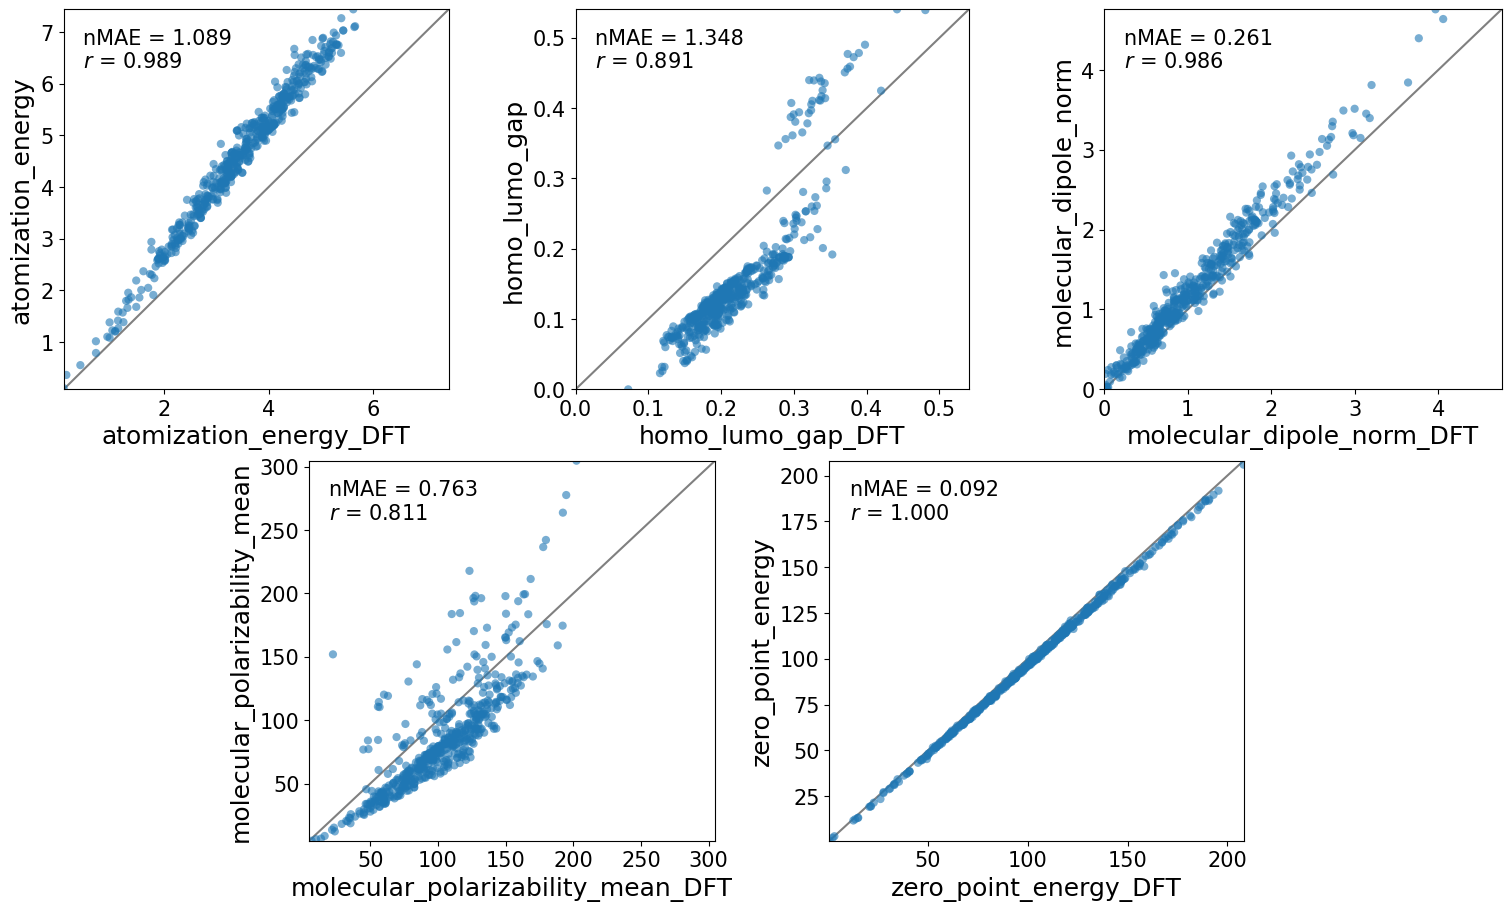

In [ ]:
# fig, axes = plt.subplots(
#     2, 3,
#     figsize=(16, 8),
#     constrained_layout=True
# )

fig = plt.figure(figsize=(15, 9), constrained_layout=True)

gs = fig.add_gridspec(2, 6)

# Top row: 3 equally sized plots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Bottom row: 2 centered plots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])

axes = [ax1, ax2, ax3, ax4, ax5]

plots = [
    ("atomization_energy", corr_series["atomization_energy"]),
    ("homo_lumo_gap", corr_series["homo_lumo_gap"]),
    ("molecular_dipole_norm", corr_series["molecular_dipole_norm"]),
    ("molecular_polarizability_mean", corr_series["molecular_polarizability_mean"]),
    ("zero_point_energy", corr_series["zero_point_energy"]),
]

scatter_kws = dict(
    s=35,               
    alpha=0.6,          
    edgecolors="none", 
    linewidths=0.0,
    rasterized=True    
)

for idx, (feature, corr) in enumerate(plots):

    nmae = nmae_series[feature]

    # ax = axes[idx // 3, idx % 3]
    ax = axes[idx]
    x = merged2_df[f"{feature}_dft"].values
    y = merged2_df[feature].values

    ax.scatter(
        x, y,
        **scatter_kws,
        zorder=2
    )

    lower = min(x.min(), y.min())
    upper = max(x.max(), y.max())

    ax.plot(
        [lower, upper],
        [lower, upper],
        linewidth=1.5,
        color="gray",
        zorder=1
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    ax.set_xlabel(f"{feature}_DFT", fontsize=18)
    ax.set_ylabel(feature, fontsize=18)
    ax.tick_params(axis='both', labelsize=15)

    ax.text(
        0.05, 0.95,
        (
            f"nMAE = {nmae:.3f}\n"
            f"$r$ = {corr:.3f}"
        ),
        transform=ax.transAxes,
        fontsize=15,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none")
    )

# plt.savefig(
#     "qmquality.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=300
# )

plt.show()

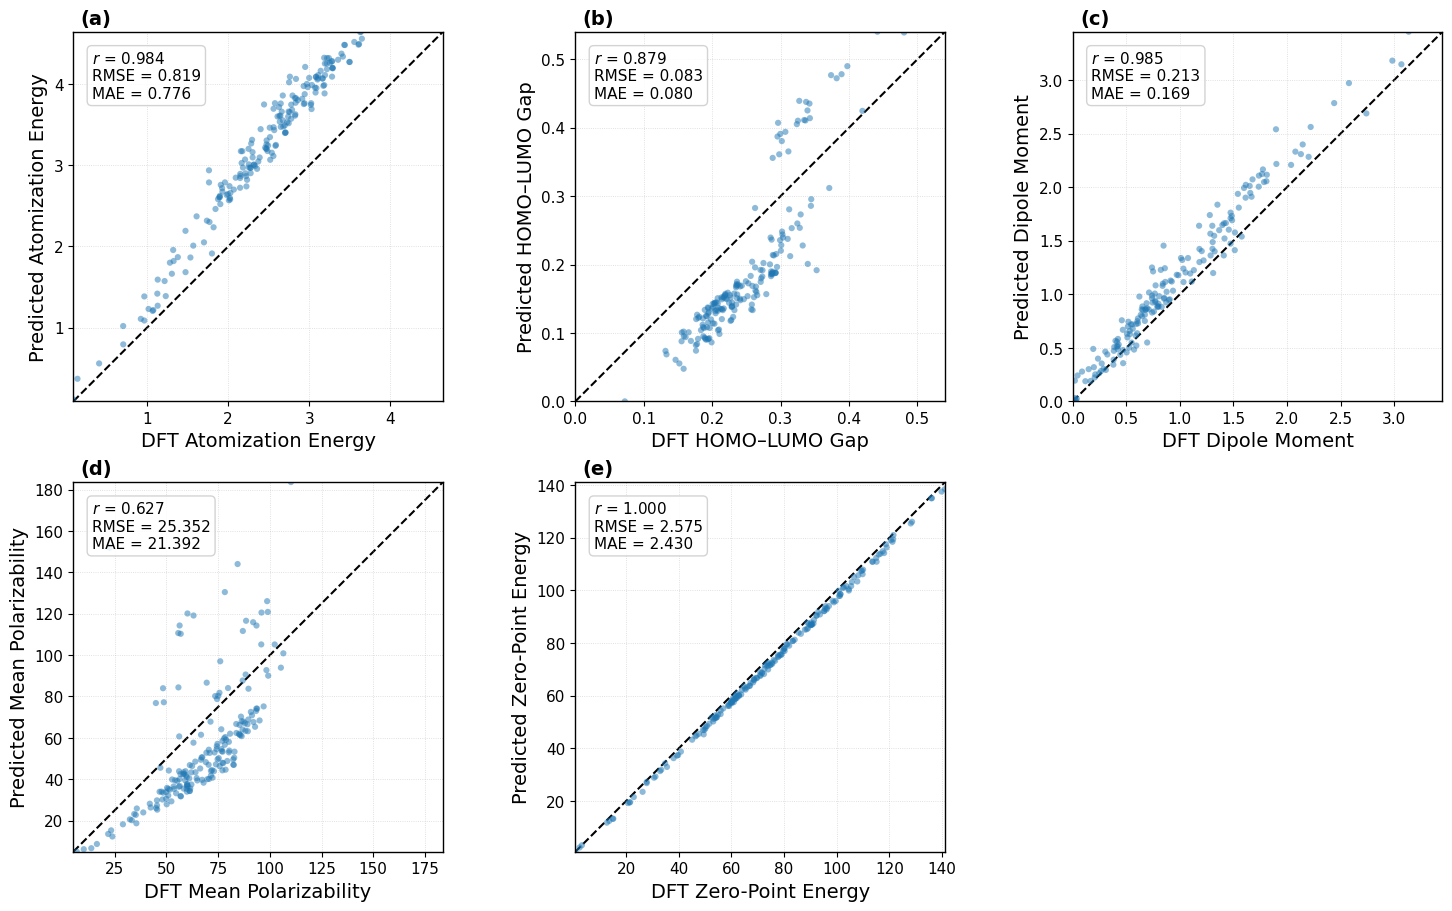

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------------
# Publication-style settings
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
})

# ------------------------------------------------------------------
# Feature names for plotting
# ------------------------------------------------------------------
labels = {
    "atomization_energy":
        "Atomization Energy",
    "homo_lumo_gap":
        "HOMO–LUMO Gap",
    "molecular_dipole_norm":
        "Dipole Moment",
    "molecular_polarizability_mean":
        "Mean Polarizability",
    "zero_point_energy":
        "Zero-Point Energy",
}

plots = [
    ("atomization_energy", corr_series["atomization_energy"]),
    ("homo_lumo_gap", corr_series["homo_lumo_gap"]),
    ("molecular_dipole_norm", corr_series["molecular_dipole_norm"]),
    (
        "molecular_polarizability_mean",
        corr_series["molecular_polarizability_mean"]
    ),
    ("zero_point_energy", corr_series["zero_point_energy"]),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    constrained_layout=True
)

scatter_kws = dict(
    s=20,
    alpha=0.5,
    edgecolors="none",
    rasterized=True
)

for idx, (feature, corr) in enumerate(plots):

    ax = axes[idx // 3, idx % 3]

    x = merged2_df[f"{feature}_dft"].values
    y = merged2_df[feature].values

    # --------------------------------------------------------------
    # Scatter
    # --------------------------------------------------------------
    ax.scatter(
        x,
        y,
        **scatter_kws,
        zorder=2
    )

    # --------------------------------------------------------------
    # Metrics
    # --------------------------------------------------------------
    mae = mean_absolute_error(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))

    # --------------------------------------------------------------
    # Parity line (y = x)
    # --------------------------------------------------------------
    lower = min(x.min(), y.min())
    upper = max(x.max(), y.max())

    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        color="black",
        zorder=1
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)

    # Equal scaling
    ax.set_aspect("equal", adjustable="box")

    # --------------------------------------------------------------
    # Labels
    # --------------------------------------------------------------
    ax.set_xlabel(f"DFT {labels[feature]}")
    ax.set_ylabel(f"Predicted {labels[feature]}")

    # --------------------------------------------------------------
    # Grid
    # --------------------------------------------------------------
    ax.grid(
        True,
        linestyle=":",
        linewidth=0.6,
        alpha=0.5
    )

    # --------------------------------------------------------------
    # Panel label
    # --------------------------------------------------------------
    ax.text(
        0.02,
        1.02,
        panel_labels[idx],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold"
    )

    # --------------------------------------------------------------
    # Statistics box
    # --------------------------------------------------------------
    ax.text(
        0.05,
        0.95,
        (
            f"$r$ = {corr:.3f}\n"
            f"RMSE = {rmse:.3f}\n"
            f"MAE = {mae:.3f}"
        ),
        transform=ax.transAxes,
        fontsize=11,
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.85,
            edgecolor="0.8"
        )
    )

# ------------------------------------------------------------------
# Remove unused sixth subplot
# ------------------------------------------------------------------
fig.delaxes(axes[1, 2])

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
# plt.savefig(
#     "sizecorr.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

plt.show()

There seems to be quite a poor correspondence between QM9 values and the GFN2-xTB values. Despite this, atomization energy and zero point energy do show a strong correlation meaning the information is still valuable.

**Better approach is**: use the optimized structures from GFN2 and run DFT calculations on them.